In [1]:
import zipfile
import glob

with zipfile.ZipFile("wykht8y7tg-1.zip", 'r') as zip_ref:
    zip_ref.extractall("battery_data")

# sorted() so file order stays identical every time you re-run this, on any machine
drive_cycle_files = sorted(glob.glob("battery_data/**/Drive Cycles/*.mat", recursive=True))
print(f"Found {len(drive_cycle_files)} drive cycle files")
for f in drive_cycle_files[:5]:
    print(f)

Found 50 drive cycle files
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_HWFET_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_UDDS_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_HWFET_UDDS_LA92_Pan18650PF.mat
battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-07-17_08.39 n10degC_US06_Pan18650PF.mat


In [2]:
train_file = [f for f in drive_cycle_files if "Cycle_2" in f][0]
print("Using:", train_file)

Using: battery_data/Panasonic 18650PF Data/-10degC/Drive Cycles/06-10-17_18.35 n10degC_Cycle_2_Pan18650PF.mat


In [3]:
from scipy.io import loadmat

mat = loadmat(train_file, squeeze_me=True, struct_as_record=False)
meas = mat["meas"]
print("Fields available:", meas._fieldnames)

Fields available: ['TimeStamp', 'Voltage', 'Current', 'Ah', 'Wh', 'Power', 'Battery_Temp_degC', 'Time', 'Chamber_Temp_degC']


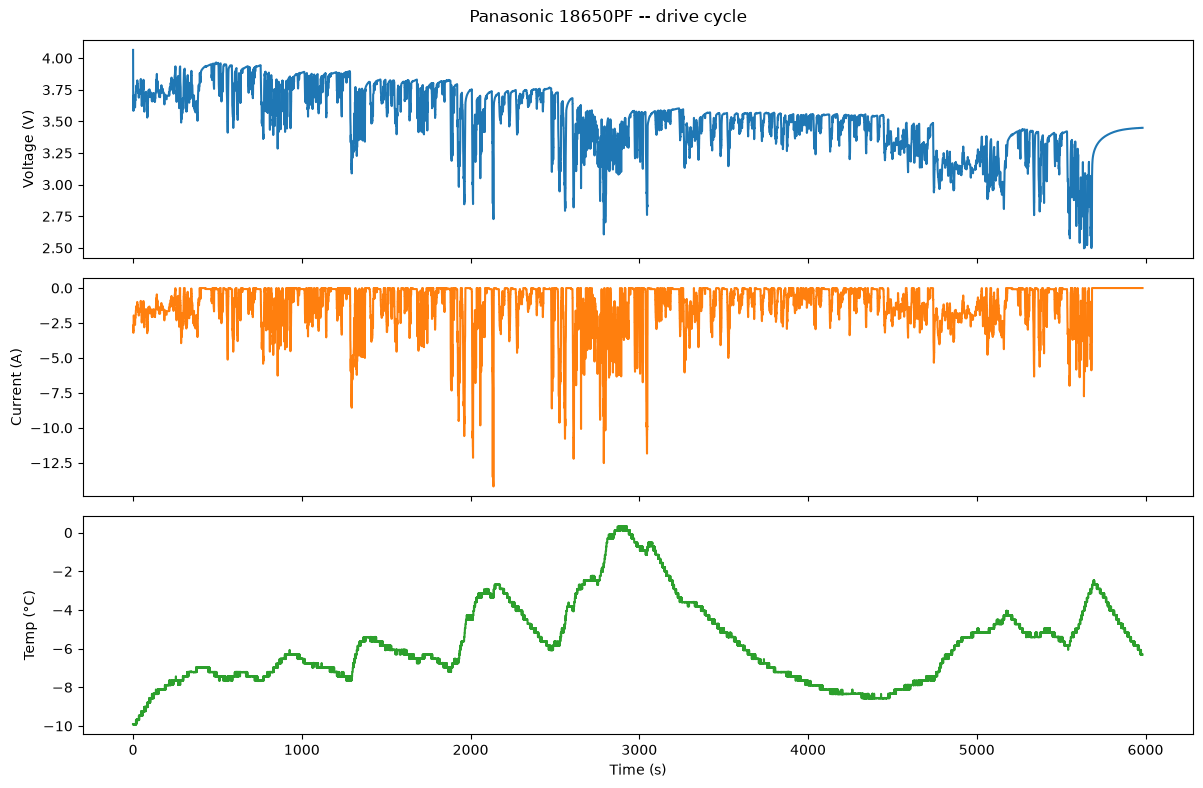

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "time_s": meas.Time,
    "voltage_V": meas.Voltage,
    "current_A": meas.Current,
    "temp_C": meas.Battery_Temp_degC,
    "ah": meas.Ah,
})

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(df["time_s"], df["voltage_V"], color="tab:blue")
axes[0].set_ylabel("Voltage (V)")
axes[1].plot(df["time_s"], df["current_A"], color="tab:orange")
axes[1].set_ylabel("Current (A)")
axes[2].plot(df["time_s"], df["temp_C"], color="tab:green")
axes[2].set_ylabel("Temp (°C)")
axes[2].set_xlabel("Time (s)")
plt.suptitle("Panasonic 18650PF -- drive cycle")
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

# The Panasonic 18650PF cell is rated at 2.9 Amp-hours when brand new
CAPACITY_AH = 2.9

time_s = df["time_s"].values
current_A = df["current_A"].values

# Time step in hours (capacity is in Amp-HOURS, current is in Amps)
dt_hours = np.diff(time_s, prepend=time_s[0]) / 3600.0

# THIS is Coulomb counting: multiply current by time-elapsed at each step,
# then keep a running total. Positive current = charging in this dataset,
# so this running total directly tracks charge gained or lost.
ah_change = np.cumsum(current_A * dt_hours)
soc_ours = (1 + (ah_change / CAPACITY_AH)) * 100
df["soc_coulomb_counting"] = soc_ours

print(df[["time_s", "current_A", "soc_coulomb_counting"]].head(10))

     time_s  current_A  soc_coulomb_counting
0  0.000000   -2.68831            100.000000
1  0.096992   -2.78141             99.997416
2  0.199999   -2.85082             99.994603
3  0.298993   -2.92268             99.991832
4  0.395995   -2.97413             99.989068
5  0.497000   -3.01088             99.986155
6  0.597995   -3.04354             99.983211
7  0.697995   -3.06314             99.980277
8  0.796998   -3.08192             99.977355
9  0.897994   -3.09499             99.974361


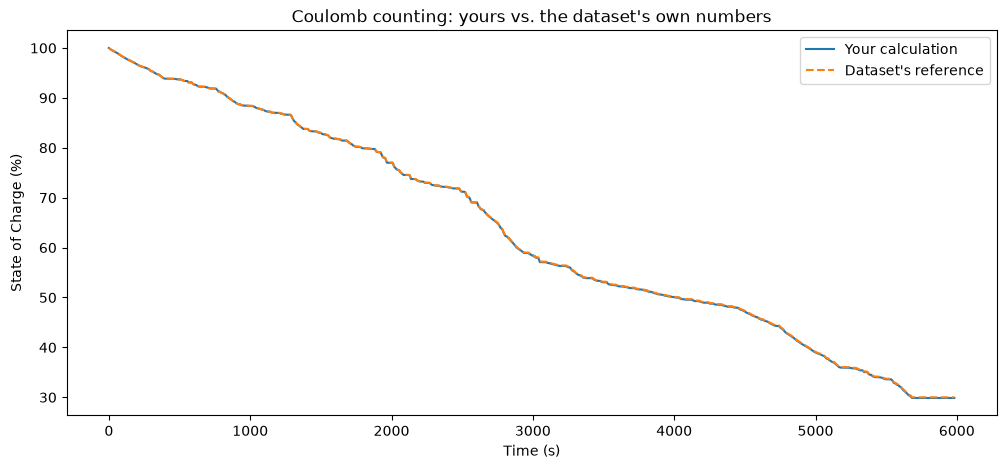

In [6]:
ah_theirs = meas.Ah
soc_theirs = (1 + (ah_theirs / CAPACITY_AH)) * 100
df["soc_dataset_reference"] = soc_theirs

plt.figure(figsize=(12, 5))
plt.plot(df["time_s"], df["soc_coulomb_counting"], label="Your calculation")
plt.plot(df["time_s"], df["soc_dataset_reference"], label="Dataset's reference", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("State of Charge (%)")
plt.title("Coulomb counting: yours vs. the dataset's own numbers")
plt.legend()
plt.show()

In [7]:
tail = df.tail(int(len(df) * 0.2))
print("Difference between your estimate and the reference, near the end:")
print((tail["soc_coulomb_counting"] - tail["soc_dataset_reference"]).describe())

Difference between your estimate and the reference, near the end:
count    11942.000000
mean        -0.122909
std          0.009929
min         -0.141857
25%         -0.138468
50%         -0.117223
75%         -0.115648
max         -0.113624
dtype: float64
